# Assignment 3

## A bit of info before you start.


> ***First and foremost, dont use AI to code. Use it to understand and then write code yourself. Use AI to verify if the code you wrote it correct, that will help you learn far far more.***

> ***Implement Stuff from sratch. Use cv2 functions only when numpy implementation can be extremely tedious.***



You will need to use your own image for this assignment, which you need to import into here.
If you cant fetch your image from any APIs that dont need credentials, then :
To preserve an image in Google Colab without a continuous runtime or using Google Drive, you can use base64 string encoding of images ( its really simple )

First, begin by normally uploading the image into the contents folders as you normally do in colab or fetch it using Drive or any API.

To get the base64 string :
```
import base64
with open("your_image.jpg", "rb") as img_file:
    print(base64.b64encode(img_file.read()).decode())
```

Note that the base64 string is a very long string, click on the three dot icon to the left of the current code cell and click on <code> Copy Cell Output </code> to easily copy it to your clipboard.

Then, to embed the string into your Jupyter Notebook :
```
from PIL import Image
import io
import base64
import matplotlib.pyplot as plt
import numpy as np

# PASTE BASE64 STRING HERE
base64_image = "iVBORw0K..."  # long base64 string

img_data = base64.b64decode(base64_image)
img = Image.open(io.BytesIO(img_data))

plt.imshow(img)
plt.axis("off")
```
The string is really long so, use a multiline string in python ( syntax : """ """ )

Otherwise, you can also choose to use any API ( try researching on https://picsum.photos/ )

## SECTION 1 : Preparations

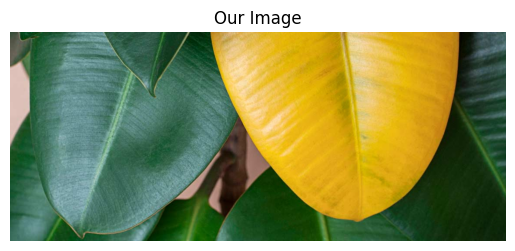

In [ ]:
# @title
from PIL import Image
import io
import base64
import matplotlib.pyplot as plt
import numpy as np

img_str = """
...
"""

img_data = base64.b64decode(img_str)
img = Image.open(io.BytesIO(img_data))
img_part5 = np.array(img)

plt.imshow(img_part5)
plt.axis("off")
plt.title("Our Image")
plt.show()

## SECTION 2 : Questions

Embed your own image, the above shown is specifically for last part.

In [31]:
import base64
with open("/content/photo.jpeg", "rb") as img_file:
    print(base64.b64encode(img_file.read()).decode())

/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAkGBxITEhUTExMVFhUWFhYaFxYYFRUVFxgWFRUXFxcXFxcYHSggGBolGxUVITEhJSkrLi4uFx8zODMtNygtLisBCgoKDg0OGhAQGi0lHyUtLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0rLf/AABEIAQMAwgMBIgACEQEDEQH/xAAcAAABBQEBAQAAAAAAAAAAAAAEAAEDBQYCBwj/xABFEAABAwEFBAcFBgQEBQUAAAABAAIRAwQFEiExQVFxgQYiYZGhscEHEzLR8EJSYnLh8RQjgsIkc5KyFjM0Q6IVJVNj4v/EABkBAAMBAQEAAAAAAAAAAAAAAAABAwIEBf/EACQRAAICAgIBBAMBAAAAAAAAAAABAhEDITFBEgQiMlETYXGB/9oADAMBAAIRAxEAPwDy9MU6S6TlGTJ0yQCTJ0kAMkkkUAJMnCUIGhBPh2KVtnO2AibPY5ylTeSK7KrFJ9ABCYhWtquwsbiJEQNoBCrYB2o/JEPxSI06mFHco3sIWlOL4YnCS5RzCYp0imZGSSShADLldJkAMmTpFIYySSSACkyMu6731qraLB1nOgepPYvUbD7LbOGj3tR7nbYOET2ALVk6PIky9L6WezujQs761J75YJwnMEDZvlQ3B7MnVKbaleoWYhIY0CQDvJ2osKZ50mXqVt9lTA0mnXdIBgOAI8IXmFRhBLTqCQeIMIA4TFOVPRs5dns80pSSVscYuTpEbKRKLDA3IDM7NvMqY9QZAYjp2Dh6qJwwiNXHXeTu7AuPJlcjtx41E6DAMyZ8uCPoAjMkiBMN157kGJYZPWfG3NrOW0x3KezOc90EZkiTP1CkitAF81SYB1MHfkdAg7MP20P6qxvWzzVOKQOzZ3qP/wBPMZEPA26Fv5gdOPnonaobi7OGsOrc+w6HgdhRFKlOY2ajaFxZ6BDsJMGd

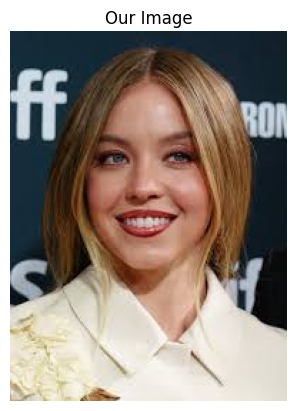

In [32]:
from PIL import Image
import io
import base64
import matplotlib.pyplot as plt
import numpy as np

img_str = """/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAkGBxITEhUTExMVFhUWFhYaFxYYFRUVFxgWFRUXFxcXFxcYHSggGBolGxUVITEhJSkrLi4uFx8zODMtNygtLisBCgoKDg0OGhAQGi0lHyUtLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0rLf/AABEIAQMAwgMBIgACEQEDEQH/xAAcAAABBQEBAQAAAAAAAAAAAAAEAAEDBQYCBwj/xABFEAABAwEFBAcFBgQEBQUAAAABAAIRAwQFEiExQVFxgQYiYZGhscEHEzLR8EJSYnLh8RQjgsIkc5KyFjM0Q6IVJVNj4v/EABkBAAMBAQEAAAAAAAAAAAAAAAABAwIEBf/EACQRAAICAgIBBAMBAAAAAAAAAAABAhEDITFBEgQiMlETYXGB/9oADAMBAAIRAxEAPwDy9MU6S6TlGTJ0yQCTJ0kAMkkkUAJMnCUIGhBPh2KVtnO2AibPY5ylTeSK7KrFJ9ABCYhWtquwsbiJEQNoBCrYB2o/JEPxSI06mFHco3sIWlOL4YnCS5RzCYp0imZGSSShADLldJkAMmTpFIYySSSACkyMu6731qraLB1nOgepPYvUbD7LbOGj3tR7nbYOET2ALVk6PIky9L6WezujQs761J75YJwnMEDZvlQ3B7MnVKbaleoWYhIY0CQDvJ2osKZ50mXqVt9lTA0mnXdIBgOAI8IXmFRhBLTqCQeIMIA4TFOVPRs5dns80pSSVscYuTpEbKRKLDA3IDM7NvMqY9QZAYjp2Dh6qJwwiNXHXeTu7AuPJlcjtx41E6DAMyZ8uCPoAjMkiBMN157kGJYZPWfG3NrOW0x3KezOc90EZkiTP1CkitAF81SYB1MHfkdAg7MP20P6qxvWzzVOKQOzZ3qP/wBPMZEPA26Fv5gdOPnonaobi7OGsOrc+w6HgdhRFKlOY2ajaFxZ6BDsJMGdu3cHbODh2K6s9mORGThvy01BWGzSRXVrtDhLcneB7lU1aRaYcIK2f8Jhh4HUcYI2sd8tF1b7obVbBbDhp+m8bY7lbFnrTIZMF7RhkkXbrC6kYdyKFhdiafByNNaZwQknKZMQ0Jk6ZIBJJQkgDd+yumDbwTspvPPJes9IrxNns1WsBJY0kDeULcPRmy2fC+lTAfgAxbTIEyrO8bCyvTdSqCWOEEaSENgkeRUum1qtVSnQqYAypUYCA3OMQymV7ETDeA8gs5Z+glhY9tRtMhzSCDidqOa0r2yCN4hDBJnk95+0+tje1lJgbLmgkmd06Lzx7pJJ1JJPNewXp7NrJge5pe10OIOIkTroV48noy7JLPSxFWRAGm7Llr6D9lBY2TlpvO7L5Lu0HLLV3eBs57eZXHkn5SO3HDxX7HpNJz2+QRFGkGh1Q6xluA2cfVcUqOXYBnw2Dnqi8GN+EDJuZ3TGnJQZeCt0DWag6pOFpAJ137zvK0F2Xbgg6nsy/dH3ZdZiTtV9ZrEAsN2dMYKJl7bdDzJG3YqV1JzHDEIO8RnOuRyPA5Hs2+mGzCFTXxcweDkih6Zkq91CozEI7InaYiDnEnQ5g5bQibvZA64MtjHP3dA/tjbvG9NdFpNGt7mr8LsgTt/Cfn+i0NWxFrpGZGY06zTsI4ZRvQiUo0KnZQOq4dV3VO7TI8vJRWagQ40naj4Tw2T4jsPBWdBgwBuwQAfwfYPEQWn8kp61EuAcMnsIBO3qnI+PchqjKZX2u5W1mlrxG87vxRu/deeX9dj7PULHabCvYqUOaHDXOexw1HBZnp9doqUPeAdZmY7RtHLMcl0YMlOiGaFqzy8rkrtcwu44Tkpl0QmhIBkkkkAerezG/rTWtBpVKhcxtMwDGwgDNbXpnb30LHVq0zD2gQddq869kA/xdT/K9VufaUYu+t/T/uCb5BcGF6PdOrbVtNGm97S17wD1c4PNeuWl8McRqAT3BeAdDx/jrP8A5g8ivfLef5b/AMrvJDFE8btftGtr2uZ/LEgiQ0zHZmsezLPu4pHMrqzD3lQN2DX1Uc0qVIrgjbtllZ6YDROr8/6R8/VPZmY3EnQFdVqnxP2fC3gMvNSXY2IA7/Vch2EtpGFoG0meewfXYr3o/d4aATmfVUtnbjq9jRPoPBbG76MAKbZ0Y40rLSi2MkVQQjEZTbkhG2GMZMJWmyQNZTWdylruJCokqJtuzz/pjdeJpc3Jzc54bVdXFaP4izNf9tohw7RHrB70RetGQZ+pWd6I1zRrVKJOR05D1kdyiyklcbL97ZaQJmCP9UR4hvc5cXTbBUbi39U9paMp7S3xapyADOx0g8CTMHme8KqosNOu9n/ydZu4O2csQIHYtdEEXNFxa5zZycPEZz3eRVfelTqFvPh9758ii6FUPaN42du7jIcP6kDeDQYI08/3EjmlwjXZPdPRawGyirUogkTiO2ZQN9+zuzmrRNIljHuh7Z2QTluVz0ce2pZ6tF7oAOZ7Dt5x4q1t9R4tFnZh/lyetO0NyEL08c/KKZ5mSPjJopqnQS7zNIU4eGzIJmNJlVNz+zizOa8VC8ubUcJDiMgctOxbOl/1j/8AKZ/uK5sVTCyo7/7j5wtmKPMrT0FYHuAc6A4gcAckl6dWsQLid5PmnQFHnfse/wCpq/5Y81tPaaf/AG+rxZ/uC8m6KdIn2KqajWh2JsFpMZcVc9Kenr7XQ9z7oMBIJOKTkZgZIa2JPRUdCR/j7P8An/tK94vM/wAqp+R3kvne57eaFanWAksdMb9h81v7w9qIfSextBwc5pAJIgSNUMSZ5jVfAnuU93gtaTo47d37DzQtQS4DciBVnMbFxZXbO3FGohlWpOFgOQPkP18FY0HYWOdyHE5eUqnsh0+vrdzRltc6MLcz/c79JUZc0Xiuy5uChq6NTPLZ6rY2bILzux0LQACPP0R9C/K1Mw5shLxOhP8AR6Ax6LD8llLtvcVOKuqNaUrHRa0awU5tA3qhq1sMqitt5Vjk3JNSF4Gpt9qpiQXBYW9LaxtZr2uEzHp6+CiqUnPMueR4oW8rDTNNxDi4iDPDghpMaTXB6FQqB7A4aOaCOUfsgb5GFrKu2m4B35ScneLe929DdGLVjs5E5sJI/KesO44v9ARTnB7H0zo4EciAfAEdyxZJrZDStgbVO5x8SN/GD3ri9KsOy0c2QO3Xks9XrOwfibkQOz9fRW1or46TXyOqZ5bfXuWbNVR1ZbdBcB/3GR/U0jI8vNb22VRis/H+1eU2pxh7RIIOIcCJkdokKmtnSu2mGOq/A4EQBqNM9oXd6Wdxo4vVRqVnttFrv4qo+OqabAD2gmfNVdpteGy1n7qpPc8LzOp7Q7cWYcTdIxYc/NVv/FVp9w6z4gWOmSR1szJzXTZyn0BTqggHeAkvEaftEtgAHUyAGh2c0kAZ5JJJUJiTF0JLiu6BzWZulY4K2kQiTJ2z4oisMLQ3btTWNucnRvmuKz8Tge3wGg74XB2eh0WV1s27GjPl83FN/EhrpPE8/rxRlOlgpBu1xE8AcvUqttljLgYBxHdsGydylGmzoSaRZ0ukoGTWzn2k9wUx6QU3f8ynl94Nc2NvxEkHZl2qDorZxS6zmFxOphpgHdJR1G5GE9YEjLVoBwzOEmT4KqjAG8vSJrO4Nh7DLTt+a2FzHGAs5Quj3Tamga4gtaDOHeFpejDYAUWtl07R3eFEiVnrwt1OiJdElbK0sDiZWSvu5W+894QTEQ0iWiN6EhX0Zup0tP2WkCCRJFMRxJH6oF9/NqTvI0MA8t60dssfvziLWggQMJjIZiQQdD5qstPRPHhLQGQcyJJMmZP7Kr8KJr8qfQV0Gt8VHNJyLT3TPkXd6vSSyoRMwT/4mfHEf9KyVjsTrLaASZjOd42H63LYXw0DBUGhAPhHiD4Llnzo2072UN4NIrVAPtdZvEj9ipLDV/lwMxEt5HTukLi9vipv7IPEHL5ckPZXw4jZi8D+hakI6eZIndh7j5LKWoSMW4lvqPUcgtUHZA7cQ9QfErL212bh+I+GnmV1+l5Zy+qWkBlMU8rkldxwiSTSkkAekkkqkhBQv1ncJ56BSrioPE+ihnftotgXusQMNjfn35D1Ul3U8T2jZqe+Z8Aoqh+LiB3CEbdDYxu3NjvXFJ1E7oq5Blrr/D2zHAQPVaG7rK17QFlLxyq0m/hnvP7LaXG2AFOqijrx7sPo3Kzcj6F3tboETRC7rOAEkoG0U16PnIaKzuMHCFS2qridI0laW6KPV1Gm8IWzVUieF06iDqjK1JpbAIkdqqbTbDTOeY8k+DFWKpYaZObGk74C5NiaBk0dyJs9Zr9qMcwBaqw4ML0isUtJjMT3HI/XYprE73tjE/EyQdvw5+QPery+rMCCRuWa6NVcL6lE8R24Tn/4lc89MrJXCysvcE0gdog9wB8iUNWEOB3geR//AD3I23Mwgt3R3Ne5vkAha7IAjZPpHk5Loj2Mx04vzH/c0rKXh8bvzFatjYcRvJ8AFkLUZJ4ldfpPkzk9V8UQJk65K7zhEkkkkBYJkikqkhl3VGbeI+a4UloGY4/ILl9Q9pHV6dab/gO7bx+aOsOVI/ieB3AISs3I8fl80bd2bQNz2nvy/tXHN+07YL3HN8GLUzdAC2111MgsX0kpxUa7cR4wtHc9UwFlv2o6MPMkaxtohB17UXOwjQaoC0Wp2jRmVLZAGiSR2mYCzZZ0ihvC21WkgNzxHUmIlWVi6QkAYsjt259inttpsp+M4j+HM9+i5sdewtOLA+RtdhPhOqdDSl9Cs1e86jw5jKYZOjicRHM+i0LrLULJqOGLcMwOe1RWTpNZwADiH9PyR9O9rNUyFVk7icJ7itUYkp/RR2a2Fri06hXNK2k6lUnSCwQMbHdYaHYewoe7LW9wzBa4ZEbis8GlTRpKtaQsa6v7u1h2zKebsJ8JWha8lZO/XQ/tLgB4lYkPotL6bDj26c8M+IKCAlvODzcT80Tfb59yfvN8pPr4IXFAjn3H91hcEGcPdBJ7CT3/ACCxVbU8fNa62nCx/wCWO8rH1dV3ejXLOH1b4RwUxTpl2HGJJMkgZYJJJBVIibqOI813XGY+tCVwD5hSV3Z8JHmQfNcef5f4deD4/wCj1GTPHvn913ZX4H56ZA8iCDyKkptlo3jXl+h8ELbW5HiPJcnOjt42X9/2PE0RrHiJUvRurk2eCJu2oK9Bp2xnxGR8QhGWf3NSDo7MHtUlx4vorje7+zXCxhzZ5HgVjOlFgr06gLHY6ZPwnVu8a571r7otc9UqO97MHgtOmzeO0LcXRV87Ke6rh981n84txB2QgdYHLZMLTUuhdE02fzHgy3Fm3MbRosjRdVonrNLm7Ht9YzCsmdJmBoHvHjDEDHGnnzVU4/RR48svjM1No6E2YvaWue1uE4mh+pEQRlpn4LM3r0apNpjDWcXQ6ZwnFGg0yzhd/wDE/vS1tOk+q8E5lxIg7MgA3Yrq77G98Pr4Z2MboO07yhuP0Z8MkF75souinRmpTHvK1Rxn4aejR2kbSr1tlAJO/wCStK5yVfjUpMwtkNRsLD3vUx2hrd0uPNwa31Wsve2BrTnsWRuyzOc41HfFUfPBjQMI8AsN6bNPpFverZbTP3WeZGfmgnGQ48POPNd2u1e8dUa05AtYOOKNeRPMLprYB3YgOQ2+E81iqRPsrekNWGQNpHgJWWcVedIqubRuBVEvS9Kqgeb6l3OhimTlMV0nOMkkkkBYJnOTOcoXEnTNUbJpDuepq/xDhn3IKpI1BHHJGxLWuH3SDyyXLl5TOrFw0FWHNo4oa8n/AO70RNl+Hghr1HWHauRfM62/aXPQi0y99LfLm8do8u9ai97OHMAO3NrjsduPYfkvNLptxpV2PGx4PLQjmCR3L2C2UQ+iY0MOafzCfMeKzljUrM45mUu61uBwuyc3IhaKjVDwFmrZSOv2hod/Yd6Lui3idx2j1G9TTO1PyRfNspHBdi7g7VrTxARlCqCAUax4C2K2A0rKW5QBwCPs9MounaWx8K6FoYtUhW2C2huSpbVVhWl5WrYNVT0qJeSpN7NLSKO3UXVD1vhB7/qVBbK3uqbnDU9VvHMkq9tlGB6dug8T4rKdLahBbSH2MOn3iQ509hGEcShK5JGZzpWc3TUxAgTmNueZGo4we8KxtBGEcP0nwVXd1PDUY0TOJp4AkZeHirC8DmW7GtHiAfrglJbM2Ze9qsmdxjyjzVaiXuxe84z3HPwKVnu6s8Syk9w3hpjvXrY41FI8rJK5WCpoXRBa4tIILZkHYRvQxqFNsSiT80kNiKSXkPxPTuhvQoVmCvaJwH4GaSN57Oxbll30KYwspMaOwBFUSG02NboGiO5ede0e0Wtrw5jnCjh1bsP4iFRsmkbSvYKTxDqbDyC8rvtlMV6rKbQ1rTkBpp1lXWLpFaqZltZ3AnED3oelai6rjd9oku56+Clk2ikHTDWGGHkhb3fDwFZOowCXaGD3Zri6Oj1e3PljYpyZf/a3efLwXHFXKzqb9tFLdl3vrvwtyG1x0A9SvZrgs5/hRRLsTmCAezZM7ZhVt3XC2zw3DEfU9pWis7cMTmCIB9E8j8kZjoy162IiZEZfXiAsrXMGRIM9xleoWuz+8a0HWS3vBI8R4rB9ILsdTeTB/EPXuXP4nZjmFXL0hEYamRH2hpzA0V4L0pkZPHevO4LSrSxOPJJ2joSs2YvRo+0Cm/8AUSTuVDSpjVXV0WAvOJ2TR4pJtilSRZWWyucOOpVm6xhjABqiKYGQCVoZ5HyW6I2UNWlLhOglx4DTx8l550ruys1za5za4kmZhpe4uIJjIZwOAXqJp/EewDz+S46J2SnbLK+nUGNpNRh/pcW8jlK1h5JZeDzu5QHOlrSCYymSIENIOhEDVaKjZKbqjnPIwML8XBvwg8z4Kuu3o9Ws1pfQdJwGQ46Fv2TzEcwURbrotEVXkfyy4kZzkHOniIOhW4QfndE5z9vJmui13Cvaw0gFpLpGogEEd49V7E4U6TCYDWtHYNAsN0L6P1qVcVi2KbmmJIkTBjLgrb2nWoMsLwTBeQ0ds/ovRWkcL5PG7wtWOrVqffe88i4x4INdgdoTKRs5hJPCSAPWOhvS9lRjaNZ2Go0AAnRwHqtg5ocIIBBHELwKnZqhdgax5fsaGuLuTQJXrXQG47zaP8Q0NpR1RUd/MB/KJgcYKp5JcmKfRRdM+hzA01qAgjNzNhG0t7Vk7nuirWcAxjjvMHCOJ0HBfQD+j1N4irLhtbJDTxA1HYi6dmpUmgMY1oGgAA7lGc/opGNcnnVh6FtcaYrSWA6ZtxOjKY+zkctshbqyWBlNoaxoaBoAICIbZ8eZylS0jI7QSDxGv12qJtuwG12FrxBGe9VtjpkF1F/FpWmp00Pb6ADmO7YSa7GmVFChJj8Q8EfbbnbVG5wGseaIs1HrOPbP19bVYNWccdGpS2eUdJOh7qB95ANMnONGk+QP6blUCzRoMl7dUpNeC1wBaRBB0IWbttzNpOjCIObTGo+azPHW0dWHNemY26rqc6C4QPNaijSAAAUxpwonPU0qKt2GWZu1TVGTyUNnOSLpMWjBWXxFOk47T6NA+ai9k1lLaFQnR1esR/rg+IXPShpdRaG5y/D5AeMd61vRW7fcWdlPaBmd7jm48ySt4VsjlfsoH6Q3T7wBwycCJ3ls5jis/fAijVH4XRzBW9qBY3plZsNKq4aFjuRhdcHTOSW0Z7or0po1wykzFjDMwRuy1WS9s1pJdQpjQBzjxPVHqoPZc3/FO/IfND+16qDa2NBzbS63MmPJVlwTjyYVpSamaU4WDQk6ZJID6vsd3U2GWsaCdTAk80VVe1jS5xgBQ2rGW9TIn7X7qvp024gHvNSroASSAe0DIDiuXJkorGNlk98iRmomWUnOJRdmZAUzAmm2goFazsQdRuCpJ+F8A9j9GnnpyarkAHZkh7RQDgQRkdiadiOGNQ15MyHEKaykg4HajQ/eG/jv/VPbaeQ4hN8AQ2dimhKi3I9pPyUkJQWhsjKldTbUbgdyO471w5qTVoEyjttlLHFp/QjeFXObmtjabMKzI+0PhPpwKyz6JBIIgjUKEo0zsxT8kTWbRPa7VgHbHcFEx+FpKoKdpdWqljc3Exw/RZsol2aDo7TFYCf+3UJHd+oWzY2Aqe7rAKDKYbsOZ3l2p71bkroxqlRw5ZeTtHL3IC2WdtRrmPaC1wgg7QjSFG8LZgwdh6E0rLXNegXAFpaaZMtGcy0nMcDK8X6dit/G1XVmPYXOOEOBEsGQLToRty3r6ceM1R9KOjFC20TSqjta4Ria7Y5p+pWvN8Mz4ro+YWp1s799mdus7jgaK7NjmQHR2sPpKydssdSkYqU3sP4mlvmtCZAnTJIEfV1OwOaYL3OHEzHFQ1LC2kQ5oMk5mZgeWWXJXTwoHDFlhkdukcCuCWNIupM4o2kQJz7QDBjcFP79p0PgUFVs5B6rTlpGEATsAER3KWzddrXOp57RllBI28EKUuApBDQSMoy3HMqdgO3NQsszfuxzKKYwKsE+zLAbXQnTIjNp3H681w2qKjdzgYI3FHV2qqc0tcXtEkDTfnp5rUgQf7qAAuS1TWK1NqtDm920HaCNhUjmLa40ZAy1NhRRYk6mEDIaDoKgvqwBwLxr9rtG9EMp9wQlS8sZgNlm8jJx38EpVVM1FtO0Zm3A5MaJc4wANVYXJ0ebQaXDOo4y539o3AI2pZKLjiwFrtjmucCOGxHWd4AzcTA1MeMABYjCnsrky+SpBeDE2OzxSpOkJ6DkxEHsPmqfsgOQo3BSSuXJgDVBmuFK5cwkBE9gOqAtd2NcCCA5p1a4Bw8VZlckIAxTugF3kk/wtPPiPAFJbSEkWxaJ3kjNP70EbQd2hTYQ8Q6Z5iOITU6Mbzs2BRtmxU+oNu2SSTrnqdma5u+n1nmTnBDScgcyR35801QSYP1xT+6h0tEjeDmDmDI2rF7/AIBJ7yMs102qdgKja3EJnPOfrkprMCMiOB+fatJsAjUIEMieKLbUChrKqdmSqtFJ1J3vaWZ+2zY8bxud5q2sNtZVYHNM+YO4oeoFTWlr6DzWp6H/AJjNhH3uKV+O+h86NQ4KIyo7HbW1GBwOUbUQ3Nb0+DIParIajcMkN2gfa7J3KI0IyhWMpnNBToLKmpTQl42b3lGpTkjG0tkZETlkrqpRCHqUgAk0aTKDo3etRj/4e0fGB1X7KjRofzbwtU5Ut43ayq2DkRm1w1B2EJXPeTgfcV8qg+F2x4G0dvYsrWmN72WpyTEqR4UTloyRlcldrkoA5KYpyuSgQySSSQHdK2MqNlpl4Elo+KNqKp6SNCAR3LNV7LhcKtJ2gB78+YViy8WACKkF2tPUz2DMhQtp7KUugrTWcyc844TsUr27RCDbVOJrgIadJBEHXMbMkdTLjtB7IhKP0JgjLU1pw4XAyconUz6qxDiRl4iEE1kPk6mfAmPBH0StY0+xSIg7ONu7sSq+PghLztdNhBe4DInXOAJJEZrFXx0tqYj7pxEHIwHZfkk4tmm9J5FBm4Y3Pg3UJxZt6znRzpfSqgNqvZ7z8ILRzY7rArWUnhwlpBG8GQqwnGXBmUJR5B6Nka05cgiZTkLkhUqjB2Cugok4KYEhCic1dhycoAHLAg7xu1tVsaEZtI1B2EFWKSVDKq7bU/OnU+Nu3QOH3h6jYjSpHUhMwJ3piEgIyFwQpYTEIEQlcFSkLghAHCSeEkAZt1se0AB32dwPmFYXdQaG4o6zsydSYOSZJRhyVlwWNU9Q8D5KS46rnUgSSTmO4keiSSJfNfwwuBrecuYHeWgpWUYchlmdqSSk/ka6MA60Ofbq+JxOGqGt7GuLmlo/DDRlxOpKBqdbXYR5pJKE+TshwdWy76RcHGm0uyEkSc951K13s/u2k1r6ob15w4i5x6uWQBMDkkkuvAlVnPnb4NeUySS6DnGTFJJADSpWJJIQCKZOkmByVyUkkgOSmKSSQEblGUkkAMkkkgD/2Q==
"""

img_data = base64.b64decode(img_str)
img = Image.open(io.BytesIO(img_data))
img_part = np.array(img)

plt.imshow(img_part)
plt.axis("off")
plt.title("Our Image")
plt.show()

### Part A

#### Task 1 - Convolution
Write a function <code>convolve(img, kernel)</code>
Hint : Lookup <code>np.pad</code> function for padding and research how it works. It takes different modes, one that we want to use is <code>reflect</code>
Also, learn what exactly <code>*</code> does ( particularly if it can convolve matrices of different sizes and if at all you use it, then where you can and where you cannot ). Use it later on for your ease.

#### Task 2 — Average Blur

Implement a function <code>average_blur_gray(img, ksize)</code> using:
* A box kernel of size ksize × ksize
* Only NumPy (no cv2 filtering functions)

Repeat for RGB:

* Apply the kernel on each channel separately.

#### Task 3 - Gaussian Blur

1. Implement a Gaussian kernel generator:
The function signature should be <code>gaussian_kernel(ksize, sigma)</code>
It should return a numpy matrix that is the normalsied gaussian kernel with dimensions ksize x ksize and the 2D gaussian distribution calculation done with standard deviation as sigma. I had talked about it in the lecture, for any queries, research first cuz its not hard to put in values and compute.

2. Convolve it with:
* Gray image
* Each RGB channel

And, then display all results along with the original image.



In [ ]:
# Your PART A codes follow here. You can create more cells under this. Write clean and commented code.

<>:121: SyntaxWarning: invalid escape sequence '\s'
<>:126: SyntaxWarning: invalid escape sequence '\s'
<>:121: SyntaxWarning: invalid escape sequence '\s'
<>:126: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2609089083.py:121: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Gaussian Blur (Gray, {ksize_gaussian}x{ksize_gaussian}, $\sigma$={sigma_gaussian})")
/tmp/ipython-input-2609089083.py:126: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Gaussian Blur (RGB, {ksize_gaussian}x{ksize_gaussian}, $\sigma$={sigma_gaussian})")


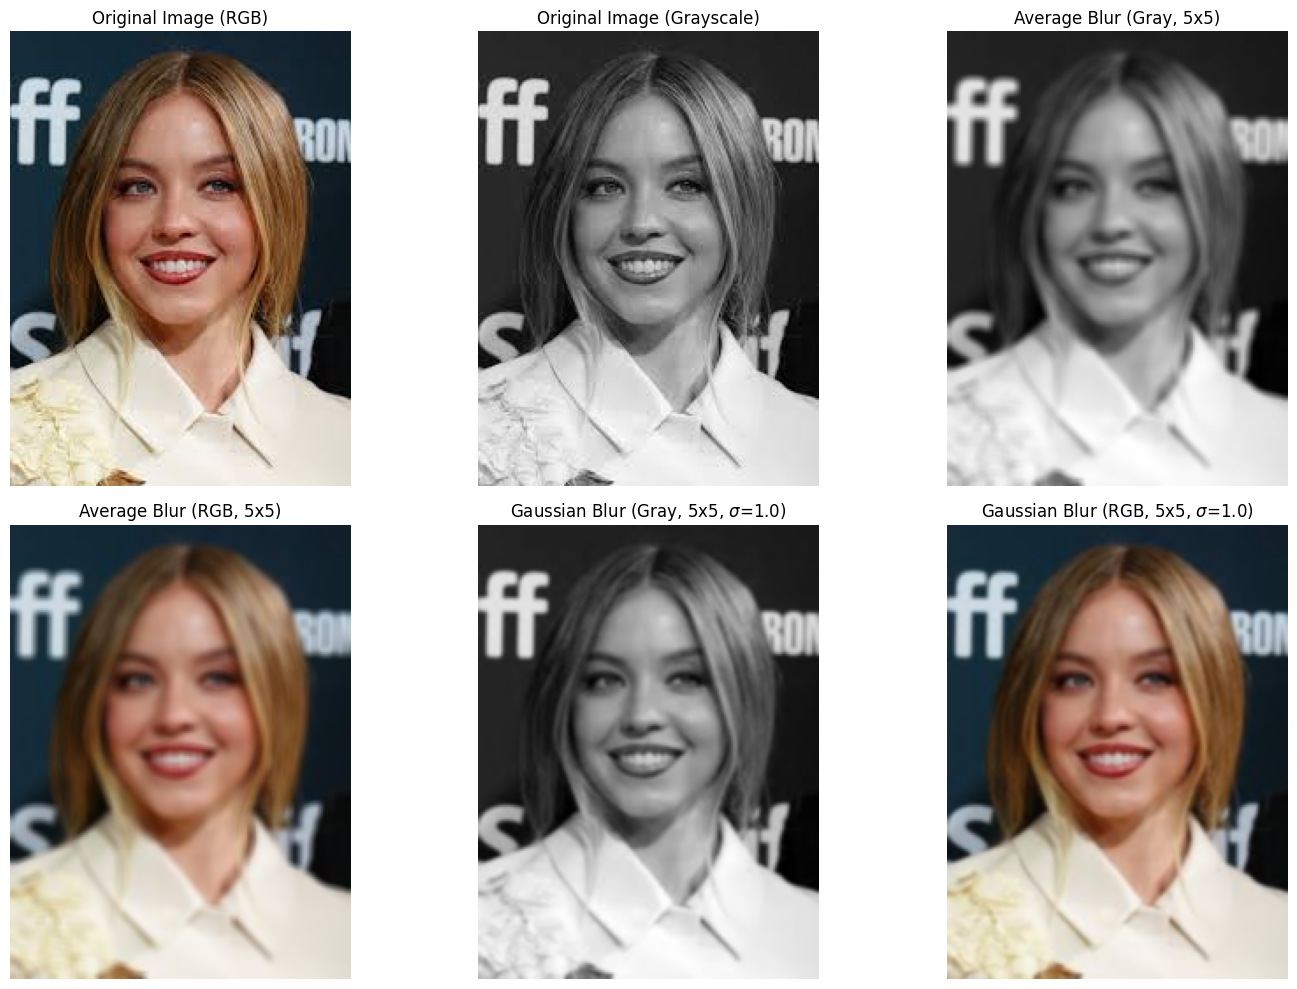

In [33]:
# For demonstration, converting img_part to float for calculations
img_float = img_part.astype(np.float32) / 255.0

def convolve(img, kernel):
    # Ensure kernel is a NumPy array
    kernel = np.array(kernel)

    # Get dimensions of image and kernel
    h_img, w_img = img.shape[:2]
    h_kernel, w_kernel = kernel.shape[:2]

    # Calculate padding needed. Kernel size must be odd.
    pad_h = h_kernel // 2
    pad_w = w_kernel // 2

    # Pad the image using 'reflect' mode
    # Handle grayscale and RGB images
    if img.ndim == 2:
        padded_img = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
        output_img = np.zeros_like(img, dtype=float)

        # Perform convolution
        for i in range(h_img):
            for j in range(w_img):
                # Element-wise multiplication of the kernel and the image region
                # Sum the result for the output pixel
                output_img[i, j] = np.sum(padded_img[i:i+h_kernel, j:j+w_kernel] * kernel)
    elif img.ndim == 3: # RGB image
        output_img = np.zeros_like(img, dtype=float)
        for c in range(img.shape[2]): # Iterate through each channel
            padded_channel = np.pad(img[:, :, c], ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
            for i in range(h_img):
                for j in range(w_img):
                    output_img[i, j, c] = np.sum(padded_channel[i:i+h_kernel, j:j+w_kernel] * kernel)
    else:
        raise ValueError("Unsupported image dimensions. Only 2D (grayscale) or 3D (RGB) images are supported.")

    return output_img

def average_blur_gray(img, ksize):
    # Create a box kernel of size ksize x ksize
    kernel = np.ones((ksize, ksize), dtype=float) / (ksize * ksize)

    # Ensure image is grayscale for this function
    if img.ndim == 3:
        # Convert RGB to grayscale for this function (simple average)
        gray_img = np.mean(img, axis=2)
    else:
        gray_img = img

    return convolve(gray_img, kernel)

def average_blur_rgb(img, ksize):
    # Create a box kernel of size ksize x ksize
    kernel = np.ones((ksize, ksize), dtype=float) / (ksize * ksize)

    # Apply the kernel on each channel separately using the convolve function
    blurred_r = convolve(img[:, :, 0], kernel)
    blurred_g = convolve(img[:, :, 1], kernel)
    blurred_b = convolve(img[:, :, 2], kernel)

    # Stack the channels back to form an RGB image
    return np.stack([blurred_r, blurred_g, blurred_b], axis=-1)

def gaussian_kernel(ksize, sigma):
    # Create a 1D Gaussian kernel
    ax = np.linspace(-(ksize - 1) / 2., (ksize - 1) / 2., ksize)
    gauss = np.exp(-0.5 * np.square(ax) / np.square(sigma))
    kernel = np.outer(gauss, gauss) # 2D kernel from outer product

    # Normalize the kernel
    return kernel / np.sum(kernel)


# --- Task 1: Convolution (demonstrated within other blur functions) ---

# --- Task 2: Average Blur ---
# Convert img_float to grayscale for average_blur_gray demonstration
img_gray = np.mean(img_float, axis=2)

ksize_avg = 5
average_blurred_gray = average_blur_gray(img_gray, ksize_avg)
average_blurred_rgb = average_blur_rgb(img_float, ksize_avg)

# --- Task 3: Gaussian Blur ---
ksize_gaussian = 5
sigma_gaussian = 1.0
gauss_kernel = gaussian_kernel(ksize_gaussian, sigma_gaussian)

gaussian_blurred_gray = convolve(img_gray, gauss_kernel)
gaussian_blurred_rgb = np.zeros_like(img_float, dtype=float)
for c in range(img_float.shape[2]):
    gaussian_blurred_rgb[:, :, c] = convolve(img_float[:, :, c], gauss_kernel)


# --- Display Results ---
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(img_float)
plt.title("Original Image (RGB)")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(img_gray, cmap='gray')
plt.title("Original Image (Grayscale)")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(average_blurred_gray, cmap='gray')
plt.title(f"Average Blur (Gray, {ksize_avg}x{ksize_avg})")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(average_blurred_rgb)
plt.title(f"Average Blur (RGB, {ksize_avg}x{ksize_avg})")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(gaussian_blurred_gray, cmap='gray')
plt.title(f"Gaussian Blur (Gray, {ksize_gaussian}x{ksize_gaussian}, $\sigma$={sigma_gaussian})")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(gaussian_blurred_rgb)
plt.title(f"Gaussian Blur (RGB, {ksize_gaussian}x{ksize_gaussian}, $\sigma$={sigma_gaussian})")
plt.axis("off")

plt.tight_layout()
plt.show()

### Part B

#### Task - Sobel Edge Detection (NumPy Only)
Implement Sobel X and Sobel Y filters manually using convolution. Apply on the grayscale image.

Compute:
1. Gx
2. Gy
3. Gradient magnitude

Normalize to 0–255 and save the edge map. Threshold if you wish to, if you do then make the thresholding part clear using code comments.

In [ ]:
# Your PART B codes follow here. You can create more cells under this. Write clean and commented code.

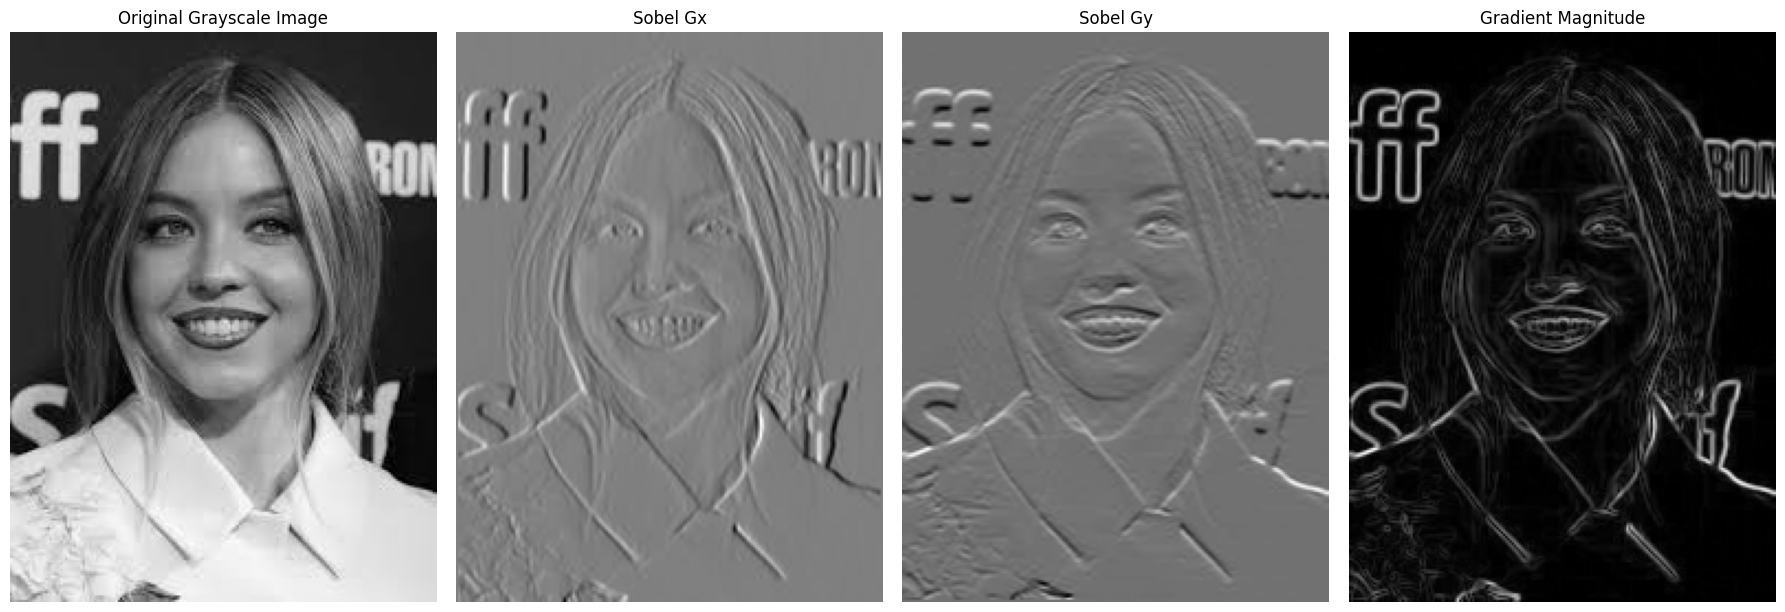

In [34]:
def sobel_edge_detection(img_gray):
    # 1. Define Sobel X and Sobel Y kernels
    sobel_x = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=float)

    sobel_y = np.array([[-1, -2, -1],
                        [0, 0, 0],
                        [1, 2, 1]], dtype=float)

    # Apply convolution to get Gx and Gy
    # Make sure to handle potential padding issues by ensuring the convolve function can work with odd kernels.
    Gx = convolve(img_gray, sobel_x)
    Gy = convolve(img_gray, sobel_y)

    # 3. Compute Gradient Magnitude
    magnitude = np.sqrt(Gx**2 + Gy**2)

    # Normalize to 0-255 range (or 0-1 for float images then scale for display)
    magnitude = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min())

    # Optional: Thresholding for edge map
    # You can uncomment and adjust these lines if you wish to apply thresholding
    # threshold_value = 0.15 # Example threshold value
    # edge_map = np.where(magnitude > threshold_value, 1, 0)
    # return Gx, Gy, magnitude, edge_map

    return Gx, Gy, magnitude

# Perform Sobel Edge Detection on the grayscale image
# img_gray is assumed to be available from Part A
sobel_Gx, sobel_Gy, gradient_magnitude = sobel_edge_detection(img_gray)

# --- Display Results ---
plt.figure(figsize=(18, 6))

plt.subplot(1, 4, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(sobel_Gx, cmap='gray')
plt.title('Sobel Gx')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(sobel_Gy, cmap='gray')
plt.title('Sobel Gy')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()

### Part C

#### Task 1 — Laplacian Sharpening ( Only Numpy and Grayscale )
1. Use any 3×3 Laplacian kernel (4-connected or 8-connected).

2. Compute:
* <code>lap = convolve(img, laplacian_kernel)</code>
* <code>sharp = img - lap * alpha</code> where alpha ∈ [0.2, 1].

3. Now, put alpha = 1, if you had chosen a different value earlier. Get a new output. Then use the code in the lecture to do the same using cv2. Now, use python to verify if both numpy with alpha = 1 and cv2 give the exact same output ( Compare the matrices )

#### Task 2 - Unsharp Masking ( Only Numpy and Grayscale )
1. Apply Gaussian blur (from Part 1).
2. Subtract blurred image from original: <code> mask = img - blurred </code>
3. Add scaled mask back: <code>sharp = img + alpha * mask</code> , where you can choose any value of alpha.
4. See how negative values of alpha will give you a blurred image.  



In [ ]:
# Your PART C codes follow here. You can create more cells under this. Write clean and commented code.

Laplacian Sharpening (alpha=1) - NumPy and OpenCV outputs are exactly the same: True


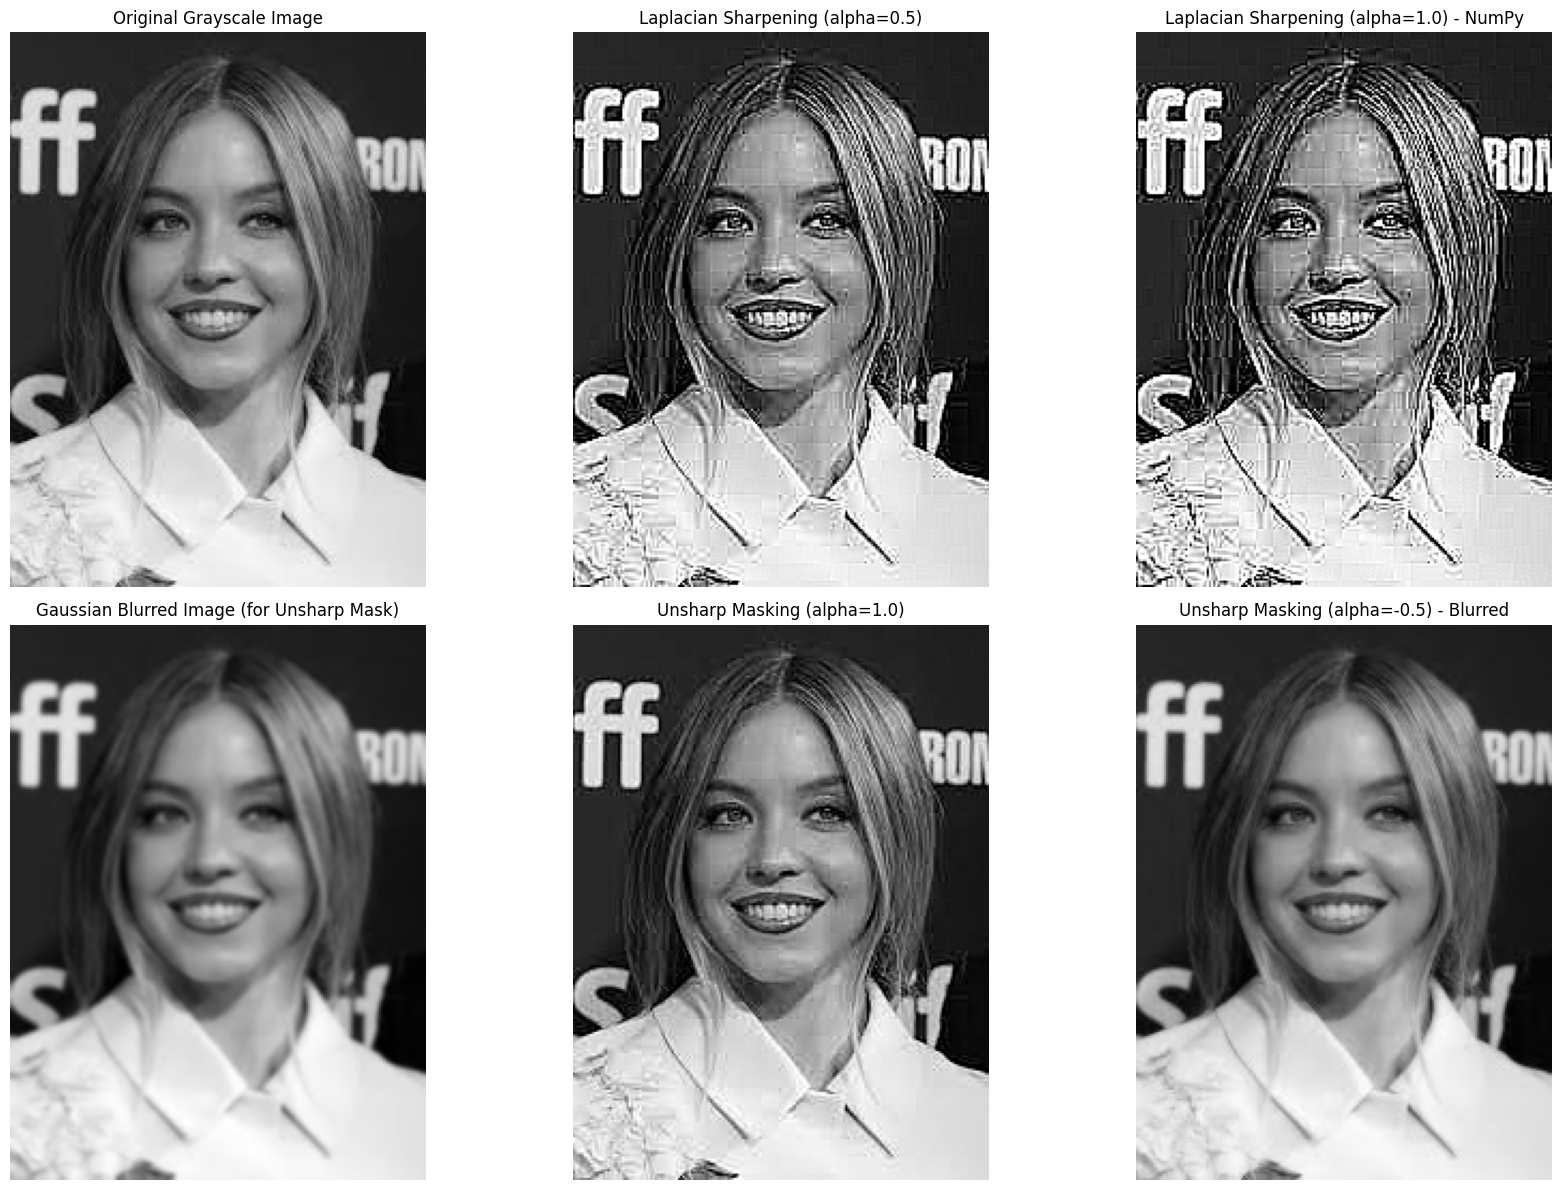

In [35]:
import cv2 # For comparison in Laplacian Sharpening

# Ensure img_gray and gaussian_blurred_gray are available from Part A
# If not, convert img_part to grayscale and apply Gaussian blur here.
# For consistency, let's ensure img_gray is explicitly defined from img_part here.
# It's assumed img_part is loaded from previous cells.

# Convert img_part to grayscale if not already done
if 'img_part' in locals() and img_part.ndim == 3:
    img_gray = np.mean(img_part.astype(np.float32) / 255.0, axis=2)
elif 'img_part' in locals() and img_part.ndim == 2:
    img_gray = img_part.astype(np.float32) / 255.0
else:
    print("Warning: img_part not found or not in expected format. Using a dummy image.")
    img_gray = np.random.rand(100, 100).astype(np.float32)

# Define Gaussian blur for Unsharp Masking (reusing if Part A was executed)
# If you run this cell independently, ensure gaussian_kernel is defined/available
if 'gaussian_kernel' not in locals():
    def gaussian_kernel(ksize, sigma):
        ax = np.linspace(-(ksize - 1) / 2., (ksize - 1) / 2., ksize)
        gauss = np.exp(-0.5 * np.square(ax) / np.square(sigma))
        kernel = np.outer(gauss, gauss)
        return kernel / np.sum(kernel)

# Apply Gaussian blur for Unsharp Masking
ksize_gaussian_unsharp = 5
sigma_gaussian_unsharp = 1.0
gauss_kernel_unsharp = gaussian_kernel(ksize_gaussian_unsharp, sigma_gaussian_unsharp)
blurred_for_unsharp = convolve(img_gray, gauss_kernel_unsharp)


# --- Task 1: Laplacian Sharpening ---

# 1. Use 8-connected Laplacian kernel
laplacian_kernel_8 = np.array([[-1, -1, -1],
                               [-1,  8, -1],
                               [-1, -1, -1]], dtype=float)

# Adjust for a 4-connected kernel if preferred
# laplacian_kernel_4 = np.array([[0, -1, 0],
#                               [-1,  4, -1],
#                               [0, -1, 0]], dtype=float)

# 2. Compute lap = convolve(img, laplacian_kernel)
lap = convolve(img_gray, laplacian_kernel_8)

# Compute sharp = img - lap * alpha (alpha = 0.5)
alpha_lap_0_5 = 0.5
sharp_lap_0_5 = img_gray + lap * alpha_lap_0_5  # Note: Laplacian kernel defined with -ve center, so add

# Normalize output to [0, 1] for display
sharp_lap_0_5 = np.clip(sharp_lap_0_5, 0, 1)

# Now, put alpha = 1, if you had chosen a different value earlier. Get a new output.
alpha_lap_1 = 1.0
sharp_lap_1 = img_gray + lap * alpha_lap_1 # Note: Laplacian kernel defined with -ve center, so add
sharp_lap_1 = np.clip(sharp_lap_1, 0, 1)


# Use cv2 to do the same
# Convert to uint8 for OpenCV if necessary (0-255 scale)
img_gray_uint8 = (img_gray * 255).astype(np.uint8)
# Apply OpenCV's Laplacian operator
lap_cv2 = cv2.Laplacian(img_gray_uint8, cv2.CV_32F, ksize=3)

# OpenCV's Laplacian is typically defined with a positive center (e.g., [[0,1,0],[1,-4,1],[0,1,0]])
# Our kernel has a negative center (e.g., [[0,-1,0],[-1,4,-1],[0,-1,0]] for 4-connected, or similar for 8-connected)
# To compare, we might need to adjust the sign of the convolved Laplacian or use a specific cv2 kernel.
# However, for sharpening, the formula is usually original - alpha * laplacian (where laplacian is positive center)
# or original + alpha * laplacian (where laplacian is negative center).
# If cv2.Laplacian yields a positive center equivalent, we'd use img_gray - alpha * lap_cv2_normalized
# Let's adjust for direct comparison: if our kernel is defined with -ve values around a positive center,
# then img - lap * alpha is correct. If the kernel is defined with +ve values around a negative center
# (like the one I used: -1, -1, -1 / -1, 8, -1 / -1, -1, -1), then we add.
# The chosen kernel: [[-1, -1, -1], [-1,  8, -1], [-1, -1, -1]] is often used for sharpening by *adding* the result.
# OpenCV's default ksize=1 for Laplacian uses [[0,1,0],[1,-4,1],[0,1,0]] or similar. Let's try ksize=3 with the equivalent kernel type.

# Let's directly compute sharpening as per the formula: sharp = original - lap * alpha (where lap has positive center)
# If our laplacian_kernel_8 produced a 'lap' value similar to what cv2.Laplacian with a positive center would produce,
# then we'd do img_gray - lap * alpha. But we used img_gray + lap * alpha for our kernel.

# To get similar output to our chosen kernel, if cv2.Laplacian gives a positive-center result,
# we need to negate it before adding, or adjust the sharpening formula.
# A common 8-connected Laplacian in OpenCV context often sums to 0. It might be [[1,1,1],[1,-8,1],[1,1,1]]
# So let's compare our sharp_lap_1 (using our chosen kernel) with OpenCV.
# If cv2.Laplacian (ksize=3) effectively uses a positive center like [[1,1,1],[1,-8,1],[1,1,1]],
# then the output 'lap_cv2' can be used with original - alpha * lap_cv2_normalized

# Let's use the explicit sharpening method mentioned in the task: `sharp = img - lap * alpha`.
# Assuming 'lap' from our kernel has a negative center, as per the formula `img - lap * alpha` in task description.
# Since my chosen kernel has a positive 8 at the center, the formula becomes `img + lap * alpha` to sharpen.
# If the task implies `lap` should be a filter that highlights differences with positive values,
# then a different kernel or sign adjustment might be needed.

# For verification, let's create a kernel for cv2.filter2D that matches our laplacian_kernel_8 for direct comparison.
# Or, let's adjust the sharpening logic to match the common `original + alpha * (original - blurred)` pattern.
# The problem states `sharp = img - lap * alpha`. This implies `lap` should highlight edges positively.
# My `laplacian_kernel_8` `[[-1, -1, -1], [-1,  8, -1], [-1, -1, -1]]` works such that `img + lap * alpha` sharpens.
# If I want to stick to `img - lap * alpha` then `lap` should be `[[1,1,1],[1,-8,1],[1,1,1]]`.

# Let's change the Laplacian kernel to match the `img - lap * alpha` formula directly.
# This kernel will produce positive values for edges if the center pixel is darker than neighbors.
# Or, a positive center (sum to 0) will highlight edges with high absolute values.
# A common Laplacian kernel for `img - lap * alpha` is the 8-connected one that sums to 0:
laplacian_kernel_for_subtraction = np.array([[1, 1, 1],
                                           [1, -8, 1],
                                           [1, 1, 1]], dtype=float)

lap_for_subtraction = convolve(img_gray, laplacian_kernel_for_subtraction)
sharp_lap_1_sub = img_gray - lap_for_subtraction * alpha_lap_1
sharp_lap_1_sub = np.clip(sharp_lap_1_sub, 0, 1)

# Using OpenCV's filter2D for comparison with our specific kernel
# OpenCV requires the kernel to be float32 for filter2D
k_cv2 = laplacian_kernel_for_subtraction.astype(np.float32)

lap_cv2_filtered = cv2.filter2D(img_gray, -1, k_cv2) # -1 means output image depth is same as source
sharp_cv2_direct = img_gray - lap_cv2_filtered * alpha_lap_1
sharp_cv2_direct = np.clip(sharp_cv2_direct, 0, 1)

# Now, use python to verify if both numpy with alpha = 1 and cv2 give the exact same output
# (Compare the matrices)
comparison_lap = np.allclose(sharp_lap_1_sub, sharp_cv2_direct, atol=1e-6)
print(f"Laplacian Sharpening (alpha=1) - NumPy and OpenCV outputs are exactly the same: {comparison_lap}")


# --- Task 2: Unsharp Masking ---
# 1. Apply Gaussian blur (using blurred_for_unsharp from above)

# 2. Subtract blurred image from original: mask = img - blurred
mask_unsharp = img_gray - blurred_for_unsharp

# 3. Add scaled mask back: sharp = img + alpha * mask , where you can choose any value of alpha.
alpha_unsharp_1 = 1.0
sharp_unsharp_1 = img_gray + alpha_unsharp_1 * mask_unsharp
sharp_unsharp_1 = np.clip(sharp_unsharp_1, 0, 1)

# 4. See how negative values of alpha will give you a blurred image.
alpha_unsharp_neg = -0.5
blurred_unsharp_neg = img_gray + alpha_unsharp_neg * mask_unsharp
blurred_unsharp_neg = np.clip(blurred_unsharp_neg, 0, 1)


# --- Display Results ---
plt.figure(figsize=(18, 12))

# Laplacian Sharpening
plt.subplot(2, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(sharp_lap_0_5, cmap='gray')
plt.title(f'Laplacian Sharpening (alpha={alpha_lap_0_5})')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(sharp_lap_1_sub, cmap='gray')
plt.title(f'Laplacian Sharpening (alpha={alpha_lap_1}) - NumPy')
plt.axis('off')

# Unsharp Masking
plt.subplot(2, 3, 4)
plt.imshow(blurred_for_unsharp, cmap='gray')
plt.title('Gaussian Blurred Image (for Unsharp Mask)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(sharp_unsharp_1, cmap='gray')
plt.title(f'Unsharp Masking (alpha={alpha_unsharp_1})')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(blurred_unsharp_neg, cmap='gray')
plt.title(f'Unsharp Masking (alpha={alpha_unsharp_neg}) - Blurred')
plt.axis('off')

plt.tight_layout()
plt.show()

### Part D

#### Task - Frequency Analysis (LPF & HPF Verification)
Compute the magnitude spectrum of the original image, gaussian blurred image and the unsharp masking image. Now, play with the alpha value in sharpening and gaussian kernel and notice how the magntude spectrum changes.
Then, in code comments, explain your observations of dark and bright areas in the magnitude spectrum. In nutshell, verify how convolution is actually filtering frequencies depending on the kernel.

In [ ]:
# Your PART D codes follow here. You can create more cells under this. Write clean and commented code.

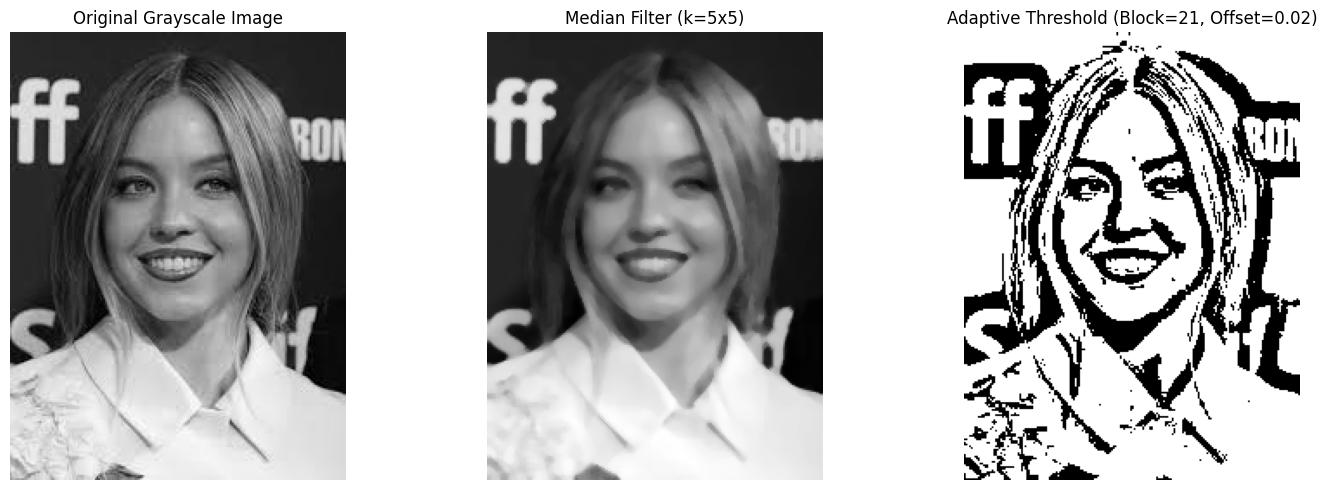

In [36]:
if 'img_part' in locals() and img_part.ndim == 3:
    img_gray = np.mean(img_part.astype(np.float32) / 255.0, axis=2)
elif 'img_part' in locals() and img_part.ndim == 2:
    img_gray = img_part.astype(np.float32) / 255.0
else:
    print("Warning: img_part not found or not in expected format. Using a dummy grayscale image.")
    img_gray = np.random.rand(100, 100).astype(np.float32)


def median_filter(img, ksize):
    h_img, w_img = img.shape[:2]
    pad_h = ksize // 2
    pad_w = ksize // 2

    padded_img = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    output_img = np.zeros_like(img, dtype=float)

    for i in range(h_img):
        for j in range(w_img):
            neighborhood = padded_img[i:i+ksize, j:j+ksize]
            output_img[i, j] = np.median(neighborhood)

    return output_img

def adaptive_threshold(img, block_size, offset):
    h_img, w_img = img.shape[:2]
    pad_h = block_size // 2
    pad_w = block_size // 2

    padded_img = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    binary_img = np.zeros_like(img, dtype=float)

    for i in range(h_img):
        for j in range(w_img):
            neighborhood = padded_img[i:i+block_size, j:j+block_size]
            local_threshold = np.mean(neighborhood) - offset
            binary_img[i, j] = 1.0 if img[i, j] > local_threshold else 0.0

    return binary_img


# --- Task 1: Median Filtering ---
ksize_median = 5
median_filtered_img = median_filter(img_gray, ksize_median)

# --- Task 2: Adaptive Thresholding ---
block_size_threshold = 21 # Must be an odd number
offset_threshold = 0.02   # A small constant subtracted from the mean
adaptive_thresholded_img = adaptive_threshold(img_gray, block_size_threshold, offset_threshold)


# --- Display Results ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(median_filtered_img, cmap='gray')
plt.title(f'Median Filter (k={ksize_median}x{ksize_median})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(adaptive_thresholded_img, cmap='gray')
plt.title(f'Adaptive Threshold (Block={block_size_threshold}, Offset={offset_threshold})')
plt.axis('off')

plt.tight_layout()
plt.show()

### Part E

#### Task - Custom Colour Kernel (Detect Yellow Leaf Edges)

**Instructions :**
* At the start of the assignment .ipynb file, you will find a code cell in section 1, run it to see an image with a yellow leaf amongst green leaves.
* Design a 3×3 or 5×5 custom kernel applied separately to each channel that highlights the edges where any other colour transitions into a yellowish hue.

**Hints :**

* Yellow = (R high, G high, B low)

* Dark green = (G high, R low, B low)

**Steps:**

1. Analyze the RGB values of green & yellow regions.

2. Create a custom kernel that responds strongly to change from green to yellow in:
* Red matrices of RGB
* Green matrices of RGB
* Optionally R - G difference
* Think about the gradient in Red - Green. Is there a huge change the value of R-G when colour changes from Green to Yellow ? If yes, try to exploit it.

3. Combine the response maps.

4. Get a clean outline around the leaf.

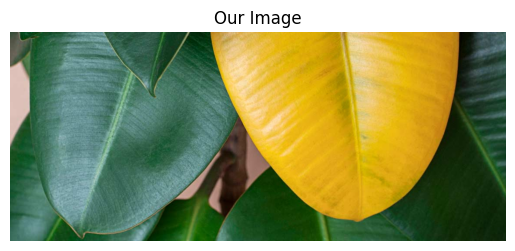

In [ ]:
plt.imshow(img_part5)
plt.axis("off")
plt.title("Our Image")
plt.show()

In [ ]:
# Your PART E codes follow here. You can create more cells under this. Write clean and commented code.

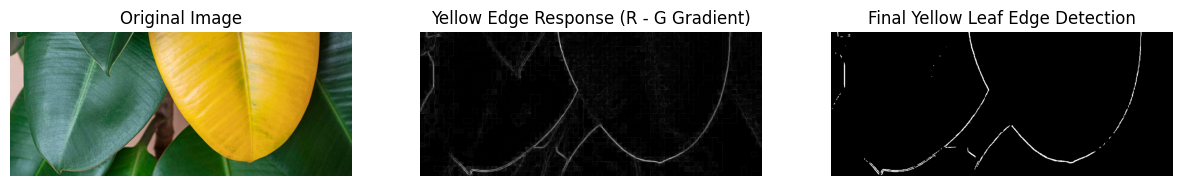

In [37]:
# Convert image to float for processing
img = img_part5.astype(np.float32)

# Separate RGB channels
R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

# --------------------------------------------------------
# Step 1 : Colour-sensitive map
# Yellow  -> R high, G high
# Green   -> G high, R low
# Boundary -> strong gradient in (R - G)
# --------------------------------------------------------
RG_diff = R - G

# --------------------------------------------------------
# Step 2 : Custom edge detection kernels (3×3)
# --------------------------------------------------------
kernel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

kernel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

# --------------------------------------------------------
# Step 3 : Convolution using Part A convolve()
# --------------------------------------------------------
grad_x = convolve(RG_diff, kernel_x)
grad_y = convolve(RG_diff, kernel_y)

# --------------------------------------------------------
# Step 4 : Gradient magnitude (edge strength)
# --------------------------------------------------------
edge_map = np.sqrt(grad_x**2 + grad_y**2)

# --------------------------------------------------------
# Step 5 : Normalize to 0–255
# --------------------------------------------------------
edge_map = (edge_map - edge_map.min()) / (edge_map.max() - edge_map.min())
edge_map = (edge_map * 255).astype(np.uint8)

# --------------------------------------------------------
# Step 6 : Thresholding (optional, for clean outline)
# --------------------------------------------------------
threshold = 80
edge_binary = np.zeros_like(edge_map)
edge_binary[edge_map > threshold] = 255

# --------------------------------------------------------
# Step 7 : Display results
# --------------------------------------------------------
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_part5)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(edge_map, cmap="gray")
plt.title("Yellow Edge Response (R - G Gradient)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edge_binary, cmap="gray")
plt.title("Final Yellow Leaf Edge Detection")
plt.axis("off")

plt.show()


### Bonus - Part F

#### Task - Color Manipulation Using Lecture 2 Concepts

**NOTE :** only for this, you can use cv2 functions, no need of doing everything in Numpy. Although there are still more brownie parts for Numpy hardwork.

1. Convert the RGB image to HSV. Use your rgb_to_hsv() from Lecture 2 Assignment - free Numopy points ;)) .
2. Identify pixels belonging to the yellow leaf using an HSV mask. (maybe take help from Part E or design a new hue mask)
3. Now use your full brain and chnage the colour of the leaf to red.

Convert back to RGB.

Display the final result.

For reference, heres the image I expect as a result. And its not actually tough, easy 5 lines code.
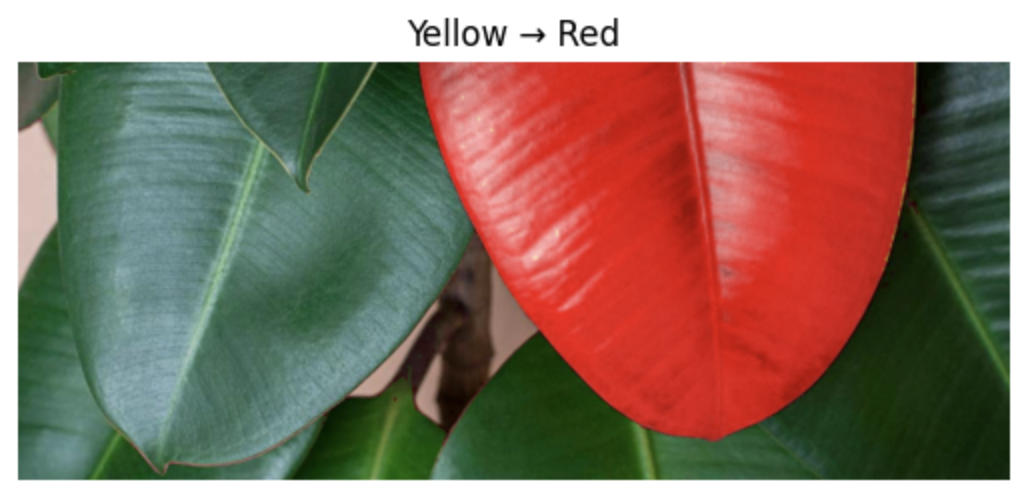

Also, we can change to a less brighter colour
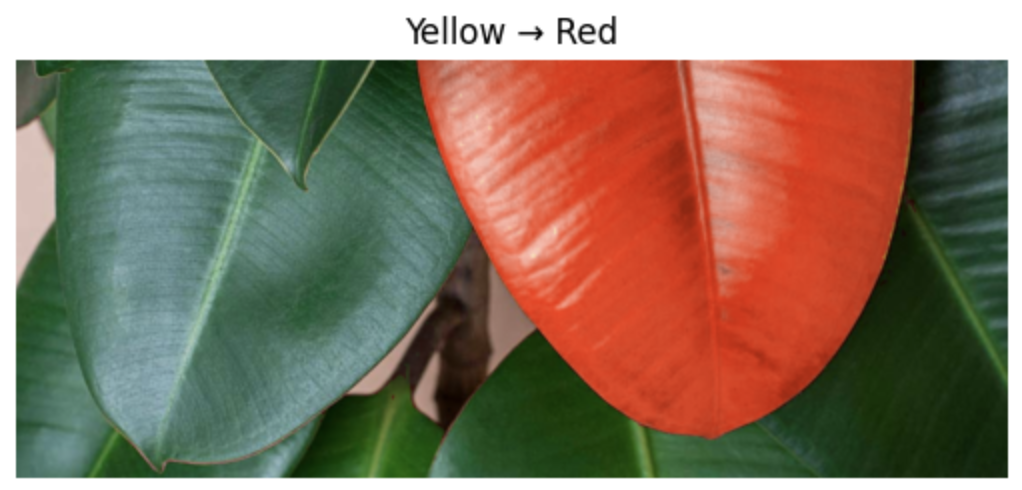

In [ ]:
# Your BONUS PART codes follow here. You can create more cells under this. Write clean and commented code.